# Chapter 5.1: Session-Based Recommendation Methods

## Learning Objectives

By the end of this notebook, you will be able to:

1. Explain the difference between **session-based** and **user-based** sequential recommendation
2. Understand **FPMC** (Factorized Personalized Markov Chains) and how it combines matrix factorization with Markov chains
3. Implement **GRU4Rec** from scratch using PyTorch, including BPR and TOP1 loss functions
4. Design session splitting strategies based on time gaps and interaction patterns
5. Model short-term user intent from session-level interaction sequences
6. Evaluate session-based recommenders with ranking metrics (MRR, Hit Rate)
7. Analyze failure modes and best practices for session-based methods

## Prerequisites

- Python 3.8+, PyTorch basics (tensors, `nn.Module`, training loops)
- Familiarity with collaborative filtering and matrix factorization (Part 1)
- Basic understanding of recurrent neural networks (GRU/LSTM)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part5/chapter_5.1_session_based.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part5/chapter_5.1_session_based.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import random
from collections import defaultdict

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.2.2


## 1. Session-Based vs User-Based Recommendation

Traditional recommendation assumes we have a **long-term user profile** — a history of rated or interacted items. But in many real scenarios:

- Users are **anonymous** (e-commerce visitors without login)
- Only the **current session** of clicks is available
- User intent can **shift dramatically** between sessions

| Aspect | User-Based Sequential | Session-Based |
|--------|----------------------|---------------|
| User ID | Required | Not required |
| History length | Long-term | Short (single session) |
| Intent | Relatively stable | Rapidly shifting |
| Cold-start | New users problematic | Every session is "cold" |
| Examples | Netflix, Spotify | E-commerce browsing, news reading |

> **💡 Concept:** A **session** is a sequence of interactions within a bounded time window. Sessions are typically split by inactivity gaps (e.g., 30 minutes) or explicit events (login/logout).

## 2. Synthetic Session Data Generation

We generate synthetic click-stream sessions to simulate e-commerce browsing behavior.

In [2]:
def generate_session_data(n_items=500, n_sessions=2000, min_len=3, max_len=20, seed=42):
    """Generate synthetic session data with category-aware click patterns."""
    rng = np.random.RandomState(seed)
    
    # Assign items to categories
    n_categories = 20
    item_category = rng.randint(0, n_categories, size=n_items)
    item_popularity = rng.power(0.5, size=n_items)  # Power-law popularity
    item_popularity /= item_popularity.sum()
    
    sessions = []
    for _ in range(n_sessions):
        session_len = rng.randint(min_len, max_len + 1)
        # Pick a dominant category for this session
        dominant_cat = rng.randint(0, n_categories)
        
        session = []
        for t in range(session_len):
            if rng.random() < 0.7:  # 70% chance to stay in dominant category
                cat_items = np.where(item_category == dominant_cat)[0]
                if len(cat_items) > 0:
                    probs = item_popularity[cat_items]
                    probs /= probs.sum()
                    item = rng.choice(cat_items, p=probs)
                else:
                    item = rng.choice(n_items, p=item_popularity)
            else:
                item = rng.choice(n_items, p=item_popularity)
            session.append(int(item))
        sessions.append(session)
    
    return sessions, item_category

N_ITEMS = 500
sessions, item_category = generate_session_data(n_items=N_ITEMS)

# Basic statistics
lengths = [len(s) for s in sessions]
print(f"Number of sessions: {len(sessions)}")
print(f"Number of items: {N_ITEMS}")
print(f"Session length — min: {min(lengths)}, max: {max(lengths)}, mean: {np.mean(lengths):.1f}")
print(f"Example session (first 8 items): {sessions[0][:8]}")

Number of sessions: 2000
Number of items: 500
Session length — min: 3, max: 20, mean: 11.6
Example session (first 8 items): [8, 348, 445, 445, 3, 212, 47, 81]


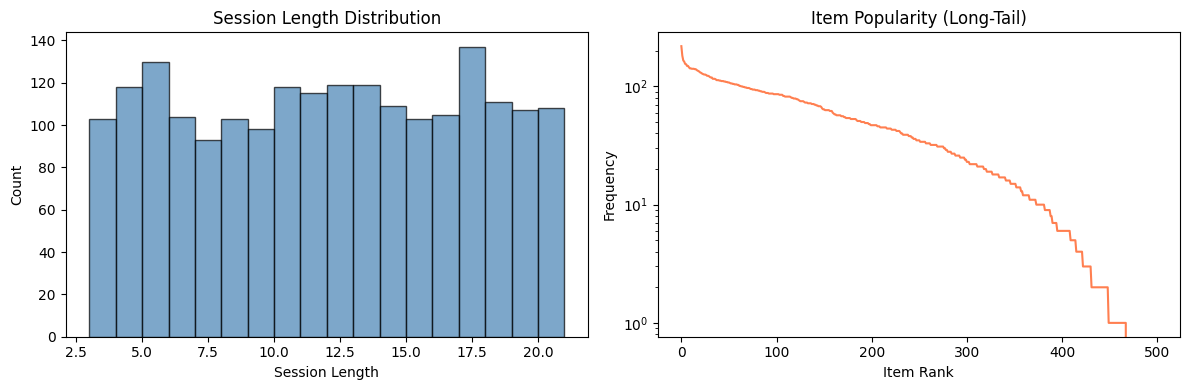

In [3]:
# Visualize session length distribution and item popularity
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(lengths, bins=range(3, 22), edgecolor="black", alpha=0.7, color="steelblue")
axes[0].set_xlabel("Session Length")
axes[0].set_ylabel("Count")
axes[0].set_title("Session Length Distribution")

# Item frequency
item_counts = np.zeros(N_ITEMS)
for s in sessions:
    for item in s:
        item_counts[item] += 1
sorted_counts = np.sort(item_counts)[::-1]
axes[1].plot(sorted_counts, color="coral")
axes[1].set_xlabel("Item Rank")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Item Popularity (Long-Tail)")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

## 3. Session Splitting Strategies

In practice, raw click-streams must be segmented into sessions. Common strategies:

1. **Time-gap splitting**: Start a new session if the gap between consecutive clicks exceeds a threshold (e.g., 30 minutes)
2. **Fixed-window splitting**: Split every N minutes regardless of activity
3. **Event-based splitting**: Use login/logout or page-change events

> **⚠️ Common Pitfall:** Choosing too small a time gap creates many trivially short sessions; too large merges distinct intents into one session. 30 minutes is a common default, but it should be tuned per domain.

In [4]:
def split_sessions_by_time_gap(events, gap_threshold=1800):
    """
    Split a stream of (user, item, timestamp) events into sessions.
    gap_threshold: seconds of inactivity to start a new session (default 30 min).
    """
    # Sort by user then timestamp
    events = sorted(events, key=lambda x: (x[0], x[2]))
    
    sessions = []
    current_session = []
    current_user = None
    last_time = None
    
    for user, item, ts in events:
        if user != current_user:
            if current_session:
                sessions.append((current_user, current_session))
            current_session = [item]
            current_user = user
            last_time = ts
        elif ts - last_time > gap_threshold:
            if current_session:
                sessions.append((current_user, current_session))
            current_session = [item]
            last_time = ts
        else:
            current_session.append(item)
            last_time = ts
    
    if current_session:
        sessions.append((current_user, current_session))
    
    return sessions

# Demo: generate synthetic timestamped events
rng = np.random.RandomState(42)
demo_events = []
for uid in range(50):
    t = 0
    for _ in range(rng.randint(5, 30)):
        t += rng.exponential(600)  # avg 10 min between clicks
        demo_events.append((uid, rng.randint(0, N_ITEMS), t))

demo_sessions = split_sessions_by_time_gap(demo_events, gap_threshold=1800)
demo_lengths = [len(s) for _, s in demo_sessions]
print(f"Generated {len(demo_sessions)} sessions from 50 users")
print(f"Avg session length: {np.mean(demo_lengths):.1f}")

Generated 91 sessions from 50 users
Avg session length: 10.0


## 4. FPMC: Factorized Personalized Markov Chains

**FPMC** (Rendle et al., 2010) combines two ideas:

- **Matrix Factorization (MF)**: captures long-term user preferences via user/item embeddings
- **Factorized Markov Chains (FMC)**: captures short-term transitions via item-to-item embeddings

The prediction for user $u$ at time $t$ transitioning from item $i$ to item $j$ is:

$$\hat{x}_{u, j}^{(t)} = \underbrace{\langle \mathbf{v}_u^{\text{MF}}, \mathbf{v}_j^{\text{MF}} \rangle}_{\text{User preference}} + \underbrace{\langle \mathbf{v}_i^{\text{MC}}, \mathbf{v}_j^{\text{MC}} \rangle}_{\text{Sequential transition}}$$

where $\mathbf{v}_u^{\text{MF}}, \mathbf{v}_j^{\text{MF}} \in \mathbb{R}^d$ are MF embeddings and $\mathbf{v}_i^{\text{MC}}, \mathbf{v}_j^{\text{MC}} \in \mathbb{R}^d$ are MC embeddings.

In [5]:
class FPMC(nn.Module):
    """Factorized Personalized Markov Chain (Rendle et al., 2010)."""
    
    def __init__(self, n_users, n_items, embed_dim=32):
        super().__init__()
        self.user_mf = nn.Embedding(n_users, embed_dim)  # User MF embedding
        self.item_mf = nn.Embedding(n_items, embed_dim)  # Item MF embedding
        self.item_mc_from = nn.Embedding(n_items, embed_dim)  # Item MC "from" embedding
        self.item_mc_to = nn.Embedding(n_items, embed_dim)    # Item MC "to" embedding
        
        nn.init.xavier_uniform_(self.user_mf.weight)
        nn.init.xavier_uniform_(self.item_mf.weight)
        nn.init.xavier_uniform_(self.item_mc_from.weight)
        nn.init.xavier_uniform_(self.item_mc_to.weight)
    
    def forward(self, user, prev_item, next_item):
        """
        user: (batch,) user IDs
        prev_item: (batch,) previous item IDs
        next_item: (batch,) candidate next item IDs
        Returns: (batch,) scores
        """
        u_mf = self.user_mf(user)
        i_mf = self.item_mf(next_item)
        mf_score = (u_mf * i_mf).sum(dim=-1)
        
        i_from = self.item_mc_from(prev_item)
        i_to = self.item_mc_to(next_item)
        mc_score = (i_from * i_to).sum(dim=-1)
        
        return mf_score + mc_score

# Quick test
fpmc = FPMC(n_users=100, n_items=N_ITEMS, embed_dim=32)
test_users = torch.randint(0, 100, (8,))
test_prev = torch.randint(0, N_ITEMS, (8,))
test_next = torch.randint(0, N_ITEMS, (8,))
scores = fpmc(test_users, test_prev, test_next)
print(f"FPMC output shape: {scores.shape}, sample scores: {scores[:4].detach().numpy()}")

FPMC output shape: torch.Size([8]), sample scores: [ 0.06290603 -0.07535602  0.08109717 -0.01197287]


## 5. GRU4Rec: Session-Based Recommendation with GRU

**GRU4Rec** (Hidasi et al., ICLR 2016) was the first deep learning approach for session-based recommendation. Key ideas:

1. Model the session as a **sequence** of item IDs fed into a GRU
2. The GRU hidden state at each step encodes the session context
3. The output is used to score all candidate items
4. Training uses **session-parallel mini-batches** for efficiency

### Architecture

$$\mathbf{h}_t = \text{GRU}(\mathbf{e}_{i_t}, \mathbf{h}_{t-1})$$
$$\hat{y}_t = \mathbf{h}_t \cdot \mathbf{E}^\top$$

where $\mathbf{e}_{i_t}$ is the item embedding and $\mathbf{E}$ is the item embedding matrix.

### Loss Functions

**BPR Loss** (Bayesian Personalized Ranking):
$$\mathcal{L}_{\text{BPR}} = -\frac{1}{N_s} \sum_{j=1}^{N_s} \log \sigma(\hat{r}_{i} - \hat{r}_{j})$$

**TOP1 Loss** (proposed in GRU4Rec):
$$\mathcal{L}_{\text{TOP1}} = \frac{1}{N_s} \sum_{j=1}^{N_s} \sigma(\hat{r}_{j} - \hat{r}_{i}) + \sigma(\hat{r}_{j}^2)$$

> **💡 Concept:** TOP1 loss regularizes the scores of negative samples toward zero, which stabilizes training compared to standard BPR.

In [6]:
class GRU4Rec(nn.Module):
    """GRU4Rec: Session-Based Recommendations with RNNs (Hidasi et al., 2016)."""
    
    def __init__(self, n_items, embed_dim=64, hidden_dim=128, n_layers=1, dropout=0.1):
        super().__init__()
        self.n_items = n_items
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        
        # Item embedding (add +1 for padding index 0)
        self.item_emb = nn.Embedding(n_items + 1, embed_dim, padding_idx=0)
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.output_layer = nn.Linear(hidden_dim, n_items)
        self.dropout = nn.Dropout(dropout)
        
        self._init_weights()
    
    def _init_weights(self):
        nn.init.xavier_uniform_(self.item_emb.weight[1:])  # Skip padding
        nn.init.xavier_uniform_(self.output_layer.weight)
        nn.init.zeros_(self.output_layer.bias)
    
    def forward(self, item_seq, lengths):
        """
        item_seq: (batch, max_len) padded item IDs (1-indexed, 0 = pad)
        lengths: (batch,) actual sequence lengths
        Returns: (batch, n_items) logits for next item
        """
        emb = self.item_emb(item_seq)  # (batch, max_len, embed_dim)
        emb = self.dropout(emb)
        
        # Pack padded sequences for efficient GRU
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        gru_out, _ = self.gru(packed)
        gru_out, _ = nn.utils.rnn.pad_packed_sequence(gru_out, batch_first=True)
        
        # Get the hidden state at the last valid position
        batch_idx = torch.arange(item_seq.size(0))
        last_hidden = gru_out[batch_idx, lengths - 1]  # (batch, hidden_dim)
        
        logits = self.output_layer(last_hidden)  # (batch, n_items)
        return logits

# Quick test
model = GRU4Rec(n_items=N_ITEMS, embed_dim=64, hidden_dim=128)
test_seq = torch.tensor([[1, 5, 10, 0, 0], [3, 7, 2, 8, 0]])
test_lens = torch.tensor([3, 4])
logits = model(test_seq, test_lens)
print(f"GRU4Rec output shape: {logits.shape}")  # (2, N_ITEMS)

GRU4Rec output shape: torch.Size([2, 500])


In [7]:
def bpr_loss(pos_scores, neg_scores):
    """BPR loss: maximize the difference between positive and negative scores."""
    return -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()

def top1_loss(pos_scores, neg_scores):
    """TOP1 loss from GRU4Rec: penalize negatives above positive + regularize."""
    diff = torch.sigmoid(neg_scores - pos_scores)
    reg = torch.sigmoid(neg_scores ** 2)
    return (diff + reg).mean()

# Demo losses
pos = torch.tensor([2.0, 1.5, 3.0])
neg = torch.tensor([0.5, 1.8, 0.1])
print(f"BPR loss: {bpr_loss(pos, neg):.4f}")
print(f"TOP1 loss: {top1_loss(pos, neg):.4f}")

BPR loss: 0.3698
TOP1 loss: 0.9453


## 6. Dataset and DataLoader for GRU4Rec

In [8]:
class SessionDataset(Dataset):
    """Dataset for session-based recommendation.
    Each sample: (input_items, target_item, input_length)
    Input is items[:-1], target is items[-1].
    Item IDs are shifted by +1 so 0 can be used for padding.
    """
    
    def __init__(self, sessions, max_len=19):
        self.samples = []
        self.max_len = max_len
        for session in sessions:
            if len(session) < 2:
                continue
            # Use all prefixes for training
            for end_idx in range(2, len(session) + 1):
                sub_session = session[:end_idx]
                inp = sub_session[:-1]
                target = sub_session[-1]
                self.samples.append((inp, target))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        inp, target = self.samples[idx]
        # Truncate to max_len and shift by +1 for padding
        inp = inp[-self.max_len:]
        length = len(inp)
        padded = [0] * (self.max_len - length) + [x + 1 for x in inp]  # Left-pad
        return (
            torch.tensor(padded, dtype=torch.long),
            torch.tensor(target, dtype=torch.long),
            torch.tensor(length, dtype=torch.long)
        )

# Split sessions into train/test
train_sessions = sessions[:1600]
test_sessions = sessions[1600:]

train_dataset = SessionDataset(train_sessions)
test_dataset = SessionDataset(test_sessions)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

Train samples: 16889, Test samples: 4214


## 7. Training GRU4Rec

In [9]:
def train_gru4rec(model, train_loader, n_epochs=5, lr=0.001):
    """Train GRU4Rec with cross-entropy loss."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    history = {"loss": []}
    
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        n_batches = 0
        
        for item_seq, target, lengths in train_loader:
            logits = model(item_seq, lengths)  # (batch, n_items)
            loss = criterion(logits, target)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            
            total_loss += loss.item()
            n_batches += 1
        
        avg_loss = total_loss / n_batches
        history["loss"].append(avg_loss)
        
        if (epoch + 1) % 2 == 0:
            print(f"Epoch {epoch+1}/{n_epochs} — Loss: {avg_loss:.4f}")
    
    return history

model = GRU4Rec(n_items=N_ITEMS, embed_dim=64, hidden_dim=128)
history = train_gru4rec(model, train_loader, n_epochs=5, lr=0.002)

Epoch 2/5 — Loss: 5.7675


Epoch 4/5 — Loss: 5.4596


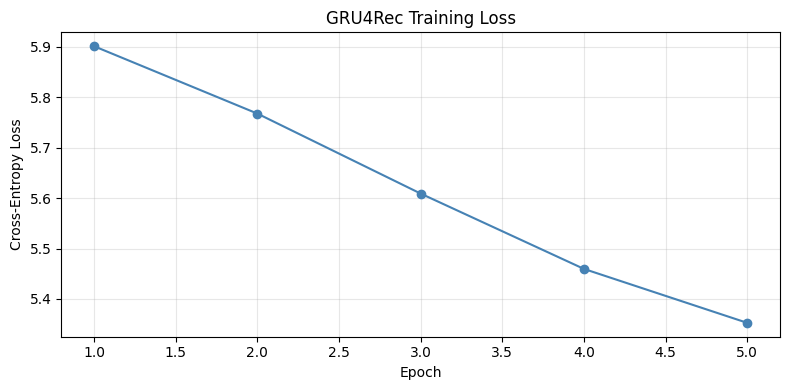

In [10]:
# Visualize training loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(history["loss"]) + 1), history["loss"], marker="o", color="steelblue")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("GRU4Rec Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Evaluation: Hit Rate and MRR

Standard metrics for session-based recommendation:

- **Hit Rate@K (HR@K)**: fraction of test cases where the true next item appears in the top-K
- **Mean Reciprocal Rank@K (MRR@K)**: average of $1/\text{rank}$ for hits

$$\text{MRR@K} = \frac{1}{|\mathcal{T}|} \sum_{t \in \mathcal{T}} \frac{1}{\text{rank}_t} \cdot \mathbb{1}[\text{rank}_t \le K]$$

In [11]:
@torch.no_grad()
def evaluate(model, test_loader, k=20):
    """Compute HR@K and MRR@K."""
    model.eval()
    hits = 0
    mrr_sum = 0.0
    total = 0
    
    for item_seq, target, lengths in test_loader:
        logits = model(item_seq, lengths)  # (batch, n_items)
        # Get top-K predictions
        _, topk_idx = logits.topk(k, dim=-1)  # (batch, k)
        
        for i in range(target.size(0)):
            true_item = target[i].item()
            preds = topk_idx[i].tolist()
            if true_item in preds:
                rank = preds.index(true_item) + 1
                hits += 1
                mrr_sum += 1.0 / rank
            total += 1
    
    hr = hits / total
    mrr = mrr_sum / total
    return hr, mrr

hr20, mrr20 = evaluate(model, test_loader, k=20)
hr10, mrr10 = evaluate(model, test_loader, k=10)

print(f"HR@10: {hr10:.4f}, MRR@10: {mrr10:.4f}")
print(f"HR@20: {hr20:.4f}, MRR@20: {mrr20:.4f}")

HR@10: 0.1604, MRR@10: 0.0528
HR@20: 0.2330, MRR@20: 0.0579


## 9. Comparing Loss Functions: BPR vs TOP1 vs Cross-Entropy

Let's train GRU4Rec with BPR loss and compare.

> **🔑 Pro Tip:** In practice, cross-entropy with sampled softmax often outperforms BPR/TOP1 for session-based rec when the item catalog is moderate in size. BPR/TOP1 shine when full softmax is too expensive.

In [12]:
def train_gru4rec_bpr(model, train_loader, n_items, n_epochs=5, lr=0.002, n_neg=50):
    """Train GRU4Rec with BPR loss using negative sampling."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": []}
    
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        n_batches = 0
        
        for item_seq, target, lengths in train_loader:
            logits = model(item_seq, lengths)  # (batch, n_items)
            batch_size = target.size(0)
            
            # Positive scores
            pos_scores = logits[torch.arange(batch_size), target]  # (batch,)
            
            # Sample negatives
            neg_items = torch.randint(0, n_items, (batch_size, n_neg))
            neg_scores = logits.gather(1, neg_items)  # (batch, n_neg)
            
            # BPR loss: average over negatives
            loss = -torch.log(
                torch.sigmoid(pos_scores.unsqueeze(1) - neg_scores) + 1e-8
            ).mean()
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            
            total_loss += loss.item()
            n_batches += 1
        
        avg_loss = total_loss / n_batches
        history["loss"].append(avg_loss)
    
    return history

# Train BPR variant
torch.manual_seed(SEED)
model_bpr = GRU4Rec(n_items=N_ITEMS, embed_dim=64, hidden_dim=128)
history_bpr = train_gru4rec_bpr(model_bpr, train_loader, N_ITEMS, n_epochs=5)

hr20_bpr, mrr20_bpr = evaluate(model_bpr, test_loader, k=20)
print(f"\nBPR — HR@20: {hr20_bpr:.4f}, MRR@20: {mrr20_bpr:.4f}")
print(f"CE  — HR@20: {hr20:.4f}, MRR@20: {mrr20:.4f}")


BPR — HR@20: 0.2098, MRR@20: 0.0503
CE  — HR@20: 0.2330, MRR@20: 0.0579


## 10. Exercises

### 🏋️ Exercise 1: Implement Session-Parallel Mini-Batching

The original GRU4Rec paper proposes **session-parallel mini-batches**: instead of padding/packing, process sessions in parallel, resetting hidden states when sessions end.

In [13]:
# 🏋️ Exercise 1: Session-Parallel Mini-Batch Iterator
#
# In session-parallel batching, we maintain B active sessions at once.
# At each step, we feed the current item from each session through the GRU.
# When a session ends, we replace it with a new session and reset its hidden state.

class SessionParallelIterator:
    def __init__(self, sessions, batch_size=64):
        self.sessions = sorted(sessions, key=len, reverse=True)
        self.batch_size = batch_size
    
    def generate_batches(self):
        """Yield (input_items, target_items, reset_mask) tuples.
        
        input_items: (batch_size,) current item for each slot
        target_items: (batch_size,) next item for each slot
        reset_mask: (batch_size,) boolean — True if this slot starts a new session
        """
        # TODO: Implement session-parallel mini-batching
        # 1. Initialize B session slots with the first B sessions
        # 2. Track the current position in each session
        # 3. At each step, yield current items and targets
        # 4. When a session ends, replace with the next available session
        #    and mark that slot for hidden state reset
        pass

# Test your implementation:
# iterator = SessionParallelIterator(train_sessions[:100], batch_size=8)
# for batch_idx, (inp, tgt, reset) in enumerate(iterator.generate_batches()):
#     if batch_idx < 3:
#         print(f"Batch {batch_idx}: reset={reset.sum().item()} slots")
#     else:
#         break

### 🏋️ Exercise 2: Implement TOP1 Loss Training

Modify the training loop to use the TOP1 loss function from GRU4Rec.

In [14]:
# 🏋️ Exercise 2: Train GRU4Rec with TOP1 Loss

def train_gru4rec_top1(model, train_loader, n_items, n_epochs=10, lr=0.002, n_neg=50):
    """Train GRU4Rec with TOP1 loss."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": []}
    
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        n_batches = 0
        
        for item_seq, target, lengths in train_loader:
            logits = model(item_seq, lengths)
            batch_size = target.size(0)
            
            # TODO: Implement TOP1 loss
            # 1. Get positive scores for target items
            # 2. Sample n_neg negative items and get their scores
            # 3. Compute TOP1 loss: sigma(neg - pos) + sigma(neg^2)
            # 4. Backpropagate and update
            
            loss = torch.tensor(0.0)  # Replace with TOP1 loss
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            
            total_loss += loss.item()
            n_batches += 1
        
        history["loss"].append(total_loss / n_batches)
    
    return history

# torch.manual_seed(SEED)
# model_top1 = GRU4Rec(n_items=N_ITEMS, embed_dim=64, hidden_dim=128)
# history_top1 = train_gru4rec_top1(model_top1, train_loader, N_ITEMS, n_epochs=10)
# hr20_top1, mrr20_top1 = evaluate(model_top1, test_loader, k=20)
# print(f"TOP1 — HR@20: {hr20_top1:.4f}, MRR@20: {mrr20_top1:.4f}")

### 🏋️ Exercise 3: Add Item Features to GRU4Rec

Extend GRU4Rec to incorporate item category features alongside item embeddings.

In [15]:
# 🏋️ Exercise 3: Feature-Augmented GRU4Rec

class GRU4RecWithFeatures(nn.Module):
    """GRU4Rec enhanced with item category features."""
    
    def __init__(self, n_items, n_categories, embed_dim=64, cat_dim=16, hidden_dim=128):
        super().__init__()
        # TODO: Implement
        # 1. Item embedding: n_items+1 -> embed_dim (with padding_idx=0)
        # 2. Category embedding: n_categories -> cat_dim
        # 3. GRU with input_size = embed_dim + cat_dim
        # 4. Output layer: hidden_dim -> n_items
        # 5. Store a mapping from item_id to category_id
        pass
    
    def forward(self, item_seq, lengths):
        # TODO: 
        # 1. Look up item embeddings
        # 2. Look up category embeddings for each item
        # 3. Concatenate item + category embeddings
        # 4. Feed through GRU and output layer
        pass

# Test:
# model_feat = GRU4RecWithFeatures(N_ITEMS, n_categories=20)
# model_feat.set_item_categories(item_category)  # Register category mapping
# logits = model_feat(test_seq, test_lens)
# print(f"Output shape: {logits.shape}")

## Summary

| Method | Year | Key Idea | Pros | Cons |
|--------|------|----------|------|------|
| FPMC | 2010 | MF + Markov Chain | Simple, interpretable | First-order only |
| GRU4Rec | 2016 | GRU on session sequences | Captures longer patterns | Sequential computation |
| GRU4Rec+ | 2018 | Improved losses (BPR-max, TOP1-max) | Better optimization | Still sequential |

**Key Takeaways:**
1. Session-based recommendation is critical for anonymous users and short-lived intents
2. FPMC provides a principled combination of long-term preference and short-term transition
3. GRU4Rec was a landmark paper that brought deep learning to session-based rec
4. Loss function choice matters: BPR, TOP1, and cross-entropy have different trade-offs
5. Next chapter: We move from RNNs to **self-attention** (SASRec, BERT4Rec)